In [8]:
import xml.etree.ElementTree as ET
import matplotlib.pyplot as plt

def read_inkml(file_path):
    tree = ET.parse(file_path)
    root = tree.getroot()

    namespace = {'inkml': 'http://www.w3.org/2003/InkML'}
    
    strokes = []
    for trace in root.findall('.//inkml:trace', namespace):
        points = []
        coords = trace.text.strip().split(',')
        for c in coords:
            values = c.strip().split()
            x, y = float(values[0]), float(values[1])
            points.append((x, y))
        strokes.append(points)

    return strokes

def read_label_from_inkml(path):
    tree = ET.parse(path)
    root = tree.getroot()

    ns = {'inkml': 'http://www.w3.org/2003/InkML'}

    label = root.find(".//inkml:annotation[@type='label']", ns)
    norm_label = root.find(".//inkml:annotation[@type='normalizedLabel']", ns)

    return {
        "label": label.text.strip() if label is not None else None,
        "normalized": norm_label.text.strip() if norm_label is not None else None
    }

def visualize_strokes(strokes):
    for stroke in strokes:
        xs = [p[0] for p in stroke]
        ys = [-p[1] for p in stroke]  
        plt.plot(xs, ys, linewidth=2)

    plt.axis("equal")
    plt.axis("off")
    plt.show()

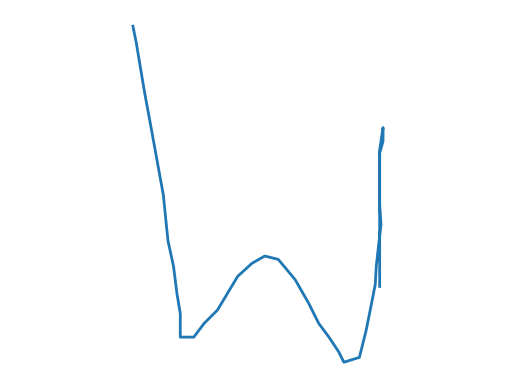

W


In [11]:
file_path = 'symbols/02ac51e03ff6783e.inkml'
stroke = read_inkml(file_path)

visualize_strokes(stroke)
print(read_label_from_inkml(file_path)['label'])